In [1]:
%load_ext autoreload
%autoreload 2

import glob
import os
import pynwb
import graph
from tqdm import tqdm
from pathlib import Path 
from datetime import datetime

import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LassoCV
from sklearn.utils import shuffle
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

import matplotlib
import matplotlib.pyplot as plt
# from matplotlib_venn import venn2
import seaborn as sns
import graph
import load_data
import single_neuron_vis

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# get value tuning 
ses_info = {'session':['031723','032823','033123','032023','040423','040723','050824',  # Bart
               '101124', '100324', '092124', '092324', '092524', '100124','100924'],
           'animal': ['Bart']*7+['London']*7}
all_sessions = pd.DataFrame(ses_info)  # London

region = 'both'
value_units = pd.DataFrame()

# for ii in range(len(all_sessions)):

ii=0
    
session = all_sessions.iloc[ii].session
animal = all_sessions.iloc[ii].animal
print(animal, session)

results = load_data.load_beh_neural(animal, session, region, 'action_on', 'trialerror==0')
spikes, df, unitNames = results['spikes'], results['beh'], results['unitNames']
df['value'] = np.maximum(0,3-df['graph_distance'].values)

Bart 031723
Building Spike Table


1499it [00:00, 4252.59it/s]


In [100]:
from scipy.optimize import minimize

def rf_rate(params, x, y):
    x0, y0, sigma, A, b = params
    return b + A * np.exp(-((x-x0)**2 + (y-y0)**2) / (2*sigma**2))

def const_rate(params, x, y):
    return params[0]*np.ones(len(x))

def neg_loglik_rf(params, x, y, k):
    lam = rf_rate(params, x, y)
    lam = np.clip(lam, 1e-6, None)
    return -(k * np.log(lam) - lam).sum()

def neg_loglik_const(params, x, y, k):
    lam = const_rate(params, x, y)
    lam = np.clip(lam, 1e-6, None)
    return -(k * np.log(lam) - lam).sum()

def fit_models(x, y, k):

    # ----- RF model -----
    res_rf = minimize(
        neg_loglik_rf,
        x0=[0, 0, 1, 5, 0.1],
        args=(x, y, k),
        bounds=[(0,3),(0,3),(1e-3,None),(0,None),(0,None)]
    )

    LL_rf = -res_rf.fun

    # ----- Constant model -----
    res_const = minimize(
        neg_loglik_const,
        x0=[np.mean(k)],
        args=(x, y, k),
        bounds=[(1e-9, None)]
    )

    LL_const = -res_const.fun

    return LL_rf, LL_const, res_rf.x


def permutation_test(x, y, k, n_perm=1000, random_state=None):

    rng = np.random.default_rng(random_state)

    # ----- observed statistic -----
    LL_rf_obs, LL_const_obs, fitted_params = fit_models(x, y, k)
    T_obs = LL_rf_obs - LL_const_obs

    T_perm = np.zeros(n_perm)

    for ii in range(n_perm):

        # shuffle spike counts relative to position
        k_perm = rng.permutation(k)

        LL_rf_p, LL_const_p, _ = fit_models(x, y, k_perm)
        T_perm[ii] = LL_rf_p - LL_const_p

    pval = np.mean(T_perm >= T_obs)

    return fitted_params, T_obs, T_perm, pval


In [85]:
from sklearn.model_selection import StratifiedKFold


In [90]:
import numpy as np
from scipy.optimize import minimize
from sklearn.model_selection import KFold
from scipy.stats import ttest_rel


# =============================
# Poisson log likelihood
# =============================
def poisson_ll(k, lam):
    lam = np.clip(lam, 1e-9, None)
    return np.sum(k * np.log(lam) - lam)


# =============================
# Gaussian RF model
# =============================
def rf_rate(p, x, y):
    x0, y0, sigma, A, base = p
    d2 = (x - x0)**2 + (y - y0)**2
    return base + A * np.exp(-d2 / (2 * sigma**2))


def fit_rf(x, y, k):

    def neg_ll(p):
        lam = rf_rate(p, x, y)
        lam = np.clip(lam, 1e-9, None)
        return -(k * np.log(lam) - lam).sum()

    init = [np.mean(x), np.mean(y), 1.5, np.max(k), np.mean(k)]
    bounds = bounds=[(0,3),(0,3),(1e-3,None),(0,None),(0,None)]

    res = minimize(neg_ll, init, bounds=bounds)
    return res.x


# =============================
# Categorical model
# =============================
def fit_cat(x, y, k):
    model = {}
    for xi in np.unique(x):
        for yi in np.unique(y):
            mask = (x == xi) & (y == yi)
            model[(xi,yi)] = np.mean(k[mask]) if mask.sum() else 1e-6
    return model


def predict_cat(model, x, y):
    return np.array([model[(xi,yi)] for xi,yi in zip(x,y)])


# =============================
# Cross-validated comparison
# =============================
def compare_models(x, y, k, nfold=5, seed=0):

    skf = StratifiedKFold(n_splits=nfold, shuffle=True, random_state=seed)

    ll_cat = []
    ll_rf = []

    for tr, te in skf.split(4*x+y,k):

        xtr, ytr, ktr = x[tr], y[tr], k[tr]
        xte, yte, kte = x[te], y[te], k[te]

        # ---- categorical
        cat_model = fit_cat(xtr, ytr, ktr)
        lam_cat = predict_cat(cat_model, xte, yte)
        ll_cat.append(poisson_ll(kte, lam_cat))

        # ---- RF
        rf_params = fit_rf(xtr, ytr, ktr)
        lam_rf = rf_rate(rf_params, xte, yte)
        ll_rf.append(poisson_ll(kte, lam_rf))

    ll_cat = np.array(ll_cat)
    ll_rf = np.array(ll_rf)

    return {
        "cat_params": np.array(list(cat_model.values())).reshape((4,4)),
        "rf_params": rf_params,
        "LL_cat": ll_cat,
        "LL_rf": ll_rf,
        "delta_LL": ll_rf - ll_cat,
        "mean_delta_LL": (ll_rf - ll_cat).mean(),
        "ttest": ttest_rel(ll_rf, ll_cat)
    }

In [91]:
results = compare_models(x, y, FR)
print(results["cat_params"])
print(results["rf_params"])
print(results["mean_delta_LL"])
print(results["ttest"])

[[0.97402596 0.9238095  0.65       0.61538464]
 [0.75949365 0.6119403  0.6086956  0.6972477 ]
 [0.8677686  0.852459   0.89705884 0.71428573]
 [0.6888889  0.7241379  0.84070796 1.        ]]
[2.96131851 2.56003665 0.22161501 1.64418716 0.77415137]
[-1.22156661 -0.49528301  2.85857127 -1.0212079   1.24376502]
0.2728557542429485
TtestResult(statistic=np.float64(0.3504127660937927), pvalue=np.float64(0.7437035794348056), df=np.int64(4))


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [72]:
mean_FR = fit_cat(x, y, FR)

In [78]:
arr = np.array(list(mean_FR.values())).reshape((4,4))

<Axes: >

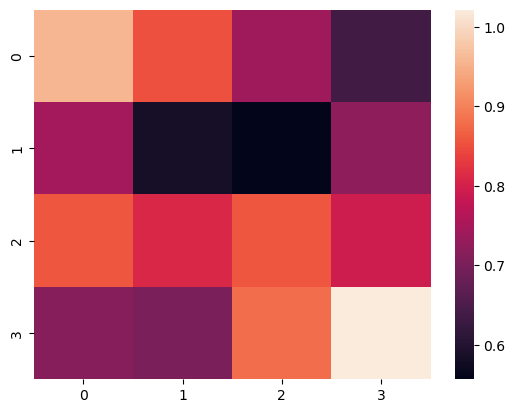

In [79]:
plt.close('all')
sns.heatmap(arr)

In [94]:
pval

np.float64(0.03)

In [92]:
T_obs, T_perm, pval = permutation_test(x, y, FR, n_perm=100)

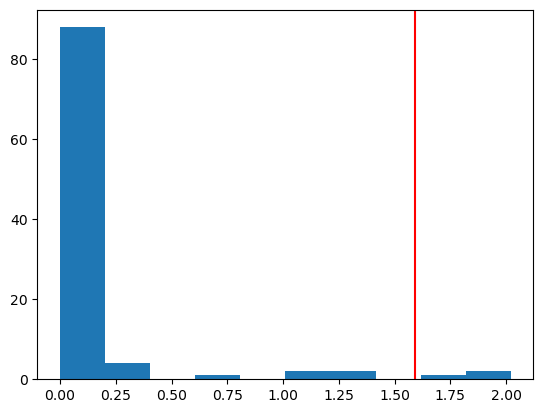

In [93]:
plt.hist(T_perm)
plt.axvline(T_obs,color='r',ls='-')

In [32]:
ll_rf = -res_rf.fun
ll_const = -res_const.fun
LLR = 2 * (ll_rf - ll_const)

(1499, 1000, 170)

In [101]:
fit_params = np.zeros((spikes.shape[2],5))
T_obs = np.zeros((spikes.shape[2]))
T_perm = np.zeros((spikes.shape[2],100))
pvals = np.zeros((spikes.shape[2],1))

for neuron_idx in tqdm(range(spikes.shape[2])):
    FR = spikes[:,500:,neuron_idx].sum(axis=1)

    x,y = np.divmod(df.node.values,4)
    
    fit_params[neuron_idx,:], T_obs[neuron_idx], T_perm[neuron_idx,:], pvals[neuron_idx] = permutation_test(x, y, FR, n_perm=100)

100%|██████████| 170/170 [02:11<00:00,  1.30it/s]


In [114]:
significant_ = np.where(pvals<0.05)[0]
it = iter(significant_)

Text(0.5, 1.0, '[0.04]')

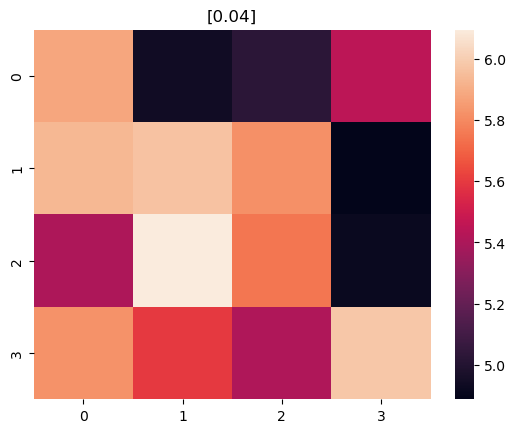

In [127]:
neuron_idx = next(it)  # 10
# for neuron_idx in tqdm(significant_):
FR = spikes[:,500:,neuron_idx].sum(axis=1)
a = np.array([FR[(x==i)&(y==j)].mean() for i in range(4) for j in range(4)]).reshape(4,4)
plt.close('all')
sns.heatmap(a)
plt.title(pvals[neuron_idx])

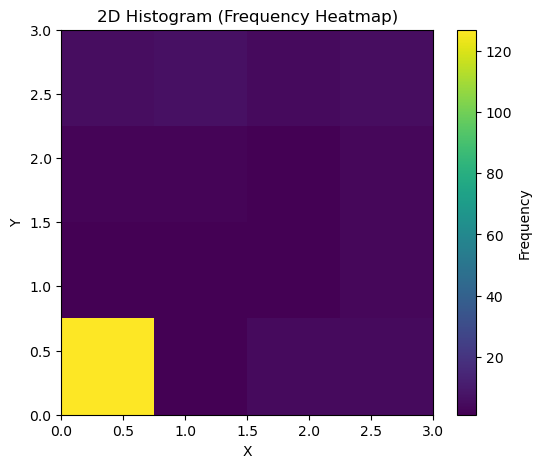

In [50]:
plt.figure(figsize=(6, 5))
plt.hist2d(fit_params[:,0], fit_params[:,1], bins=4, cmap="viridis")
plt.colorbar(label="Frequency")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Histogram (Frequency Heatmap)")
plt.show()

In [23]:
fr=np.zeros((3,4,4,100))
for x in range(4):
    for y in range(4):
        lam = rf_rate([1,3,1,3,5], x, y)
        fr[2,x,y,:] = np.random.poisson(lam, size=100)
        fr[0,x,y,:] = x
        fr[1,x,y,:] = y

In [14]:
fr[:,:,:100].mean(axis=2)

array([[4.93, 5.01, 5.98, 7.02],
       [5.11, 5.2 , 6.89, 7.72],
       [5.01, 5.49, 6.52, 6.32],
       [5.22, 4.87, 5.76, 5.28]])

<Axes: >

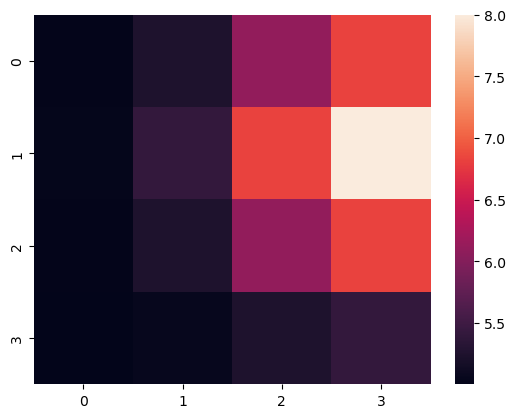

In [6]:
plt.close('all')
sns.heatmap(fr)

<Axes: >

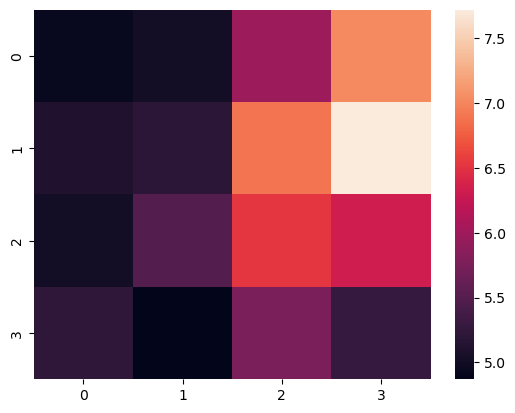

In [15]:
plt.close('all')
sns.heatmap(fr[:,:,:100].mean(axis=2))